# Tutorial 01 — Building a Perceptron in PyTorch

## Objective

This notebook implements **Tutorial 01: Building a Perceptron** using PyTorch.

The tutorial covers:

- Building a perceptron from scratch
- Understanding weights and bias
- Weighted sum calculation
- Step activation function
- Loading the Iris dataset
- Training and testing
- Manual input prediction
- Replacing the step function with sigmoid
- Replacing labels `1, -1` with `1, 0`

The classification task is:

> Predict whether an Iris flower is **Iris-setosa** or **not Iris-setosa**.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load the Iris Dataset

The Iris dataset contains 150 samples and 4 input features:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

The original dataset has 3 classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

For this tutorial, this is converted into a binary classification problem:

- `Iris-setosa` = positive class
- Other species = negative class


In [2]:
iris = load_iris()

X = iris.data
species_names = iris.target_names
y_original = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y_original
df["species"] = [species_names[i] for i in y_original]

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Prepare Labels for Classic Perceptron

For the first implementation:

- `Iris-setosa` → `1`
- Not `Iris-setosa` → `-1`

This matches the classic perceptron step function output.


In [3]:
y_step = np.where(y_original == 0, 1, -1)

print("Input shape:", X.shape)
print("Labels shape:", y_step.shape)
print("Unique labels:", np.unique(y_step))


Input shape: (150, 4)
Labels shape: (150,)
Unique labels: [-1  1]


## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_step,
    test_size=0.25,
    random_state=42,
    stratify=y_step
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nFirst 2 training samples:")
print(X_train[:2])

print("\nFirst 2 training labels:")
print(y_train[:2])


Training samples: 112
Testing samples: 38

First 2 training samples:
[[4.8 3.1 1.6 0.2]
 [4.6 3.6 1.  0.2]]

First 2 training labels:
[1 1]


## 5. Convert Data to PyTorch Tensors

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=device)

print(X_train_t.shape)
print(y_train_t.shape)


torch.Size([112, 4])
torch.Size([112])


## 6. Perceptron Class from Scratch

The perceptron calculates:

\[
z = XW + b
\]

Then applies a step function:

\[
\hat{y} =
\begin{cases}
1, & z \geq 0 \\
-1, & z < 0
\end{cases}
\]

The weight update rule is:

\[
W_i = W_i + \eta(y - \hat{y})X_i
\]

The bias update rule is:

\[
b = b + \eta(y - \hat{y})
\]


In [6]:
class TorchPerceptron:
    def __init__(self, n_features, learning_rate=0.01, n_iter=10):
        self.learning_rate = learning_rate
        self.n_iter = n_iter

        # Initialize weights and bias to zero
        self.weights = torch.zeros(n_features, dtype=torch.float32, device=device)
        self.bias = torch.tensor(0.0, dtype=torch.float32, device=device)

        self.errors_ = []

    def weighted_sum(self, X):
        return torch.matmul(X, self.weights) + self.bias

    def predict(self, X):
        z = self.weighted_sum(X)
        return torch.where(z >= 0.0, torch.tensor(1.0, device=device), torch.tensor(-1.0, device=device))

    def fit(self, X, y):
        for epoch in range(self.n_iter):
            errors = 0

            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors_.append(errors)
            print(f"Epoch {epoch + 1}/{self.n_iter}, Errors: {errors}")

        return self


## 7. Train the Classic Perceptron

In [7]:
perceptron = TorchPerceptron(
    n_features=X_train_t.shape[1],
    learning_rate=0.01,
    n_iter=10
)

perceptron.fit(X_train_t, y_train_t)

print("\nFinal weights:", perceptron.weights.detach().cpu().numpy())
print("Final bias:", perceptron.bias.item())


Epoch 1/10, Errors: 7
Epoch 2/10, Errors: 0
Epoch 3/10, Errors: 0
Epoch 4/10, Errors: 0
Epoch 5/10, Errors: 0
Epoch 6/10, Errors: 0
Epoch 7/10, Errors: 0
Epoch 8/10, Errors: 0
Epoch 9/10, Errors: 0
Epoch 10/10, Errors: 0

Final weights: [ 0.014       0.086      -0.15999997 -0.06599999]
Final bias: 0.019999999552965164


## 8. Plot Training Errors

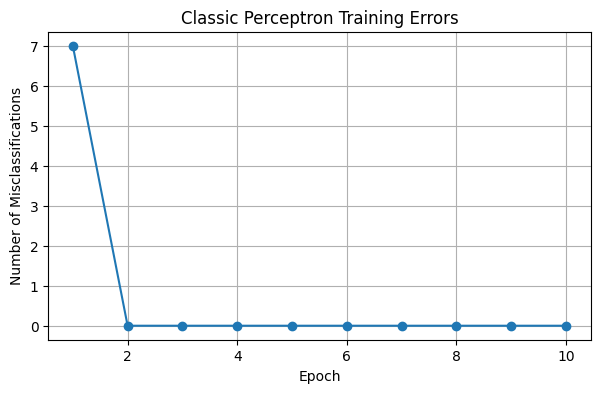

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(perceptron.errors_) + 1), perceptron.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.title("Classic Perceptron Training Errors")
plt.grid(True)
plt.show()


## 9. Test the Classic Perceptron

In [9]:
with torch.no_grad():
    y_pred_t = perceptron.predict(X_test_t)

y_pred = y_pred_t.detach().cpu().numpy()
y_true = y_test_t.detach().cpu().numpy()

accuracy = accuracy_score(y_true, y_pred)

print("Predicted labels:")
print(y_pred)

print("\nActual labels:")
print(y_true)

print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Predicted labels:
[-1. -1. -1. -1. -1. -1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1.
 -1. -1.  1. -1.  1. -1.  1. -1. -1.  1. -1. -1.  1.  1. -1. -1. -1. -1.
  1. -1.]

Actual labels:
[-1. -1. -1. -1. -1. -1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1.
 -1. -1.  1. -1.  1. -1.  1. -1. -1.  1. -1. -1.  1.  1. -1. -1. -1. -1.
  1. -1.]

Accuracy: 100.0 %

Confusion Matrix:
[[25  0]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

        -1.0       1.00      1.00      1.00        25
         1.0       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



## 10. Manual Input Prediction

Enter four values:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

The model predicts whether the flower is **Iris-setosa** or **not Iris-setosa**.


In [10]:
def predict_manual_step(sepal_length, sepal_width, petal_length, petal_width):
    manual_input = torch.tensor(
        [sepal_length, sepal_width, petal_length, petal_width],
        dtype=torch.float32,
        device=device
    )

    prediction = perceptron.predict(manual_input).item()

    if prediction == 1:
        return "Iris-setosa"
    else:
        return "Not Iris-setosa"


# Example manual input
result = predict_manual_step(
    sepal_length=5.1,
    sepal_width=3.5,
    petal_length=1.4,
    petal_width=0.2
)

print("Prediction:", result)


Prediction: Iris-setosa


## 11. Interactive Manual Input

Run this cell if you want to type values manually.


In [11]:
# Uncomment this cell when you want to enter values manually.

# sepal_length = float(input("Enter sepal length: "))
# sepal_width = float(input("Enter sepal width: "))
# petal_length = float(input("Enter petal length: "))
# petal_width = float(input("Enter petal width: "))

# result = predict_manual_step(sepal_length, sepal_width, petal_length, petal_width)
# print("Prediction:", result)


# Task Modification: Sigmoid Activation

The tutorial task asks to:

1. Replace the step function with sigmoid
2. Replace labels `1, -1` with `1, 0`

For this version:

- `Iris-setosa` → `1`
- Not `Iris-setosa` → `0`

A sigmoid function outputs a probability between 0 and 1:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

For final classification:

- Probability `>= 0.5` → class `1`
- Probability `< 0.5` → class `0`


## 12. Prepare Labels for Sigmoid Model

In [12]:
y_sigmoid = np.where(y_original == 0, 1, 0)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y_sigmoid,
    test_size=0.25,
    random_state=42,
    stratify=y_sigmoid
)

X_train_s_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
X_test_s_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)

y_train_s_t = torch.tensor(y_train_s, dtype=torch.float32, device=device).view(-1, 1)
y_test_s_t = torch.tensor(y_test_s, dtype=torch.float32, device=device).view(-1, 1)

print("Unique labels:", np.unique(y_sigmoid))
print("Training label shape:", y_train_s_t.shape)


Unique labels: [0 1]
Training label shape: torch.Size([112, 1])


## 13. Define Sigmoid Perceptron Using PyTorch

This is still a single-neuron model, but now it is trained using:

- Linear layer
- Sigmoid activation
- Binary Cross Entropy loss
- Gradient descent through PyTorch autograd


In [13]:
class SigmoidPerceptron(torch.nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = torch.nn.Linear(n_features, 1)

    def forward(self, x):
        z = self.linear(x)
        return torch.sigmoid(z)


sigmoid_model = SigmoidPerceptron(n_features=X_train_s_t.shape[1]).to(device)

criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(sigmoid_model.parameters(), lr=0.01)

print(sigmoid_model)


SigmoidPerceptron(
  (linear): Linear(in_features=4, out_features=1, bias=True)
)


## 14. Train the Sigmoid Perceptron

In [14]:
epochs = 200
loss_history = []

for epoch in range(epochs):
    sigmoid_model.train()

    y_prob = sigmoid_model(X_train_s_t)
    loss = criterion(y_prob, y_train_s_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        with torch.no_grad():
            y_pred_train = (y_prob >= 0.5).float()
            train_acc = (y_pred_train == y_train_s_t).float().mean().item()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}, Training Accuracy: {train_acc * 100:.2f}%")


Epoch 20/200, Loss: 0.6386, Training Accuracy: 66.96%
Epoch 40/200, Loss: 0.5584, Training Accuracy: 66.96%
Epoch 60/200, Loss: 0.4933, Training Accuracy: 66.96%
Epoch 80/200, Loss: 0.4388, Training Accuracy: 66.96%
Epoch 100/200, Loss: 0.3931, Training Accuracy: 69.64%
Epoch 120/200, Loss: 0.3547, Training Accuracy: 89.29%
Epoch 140/200, Loss: 0.3222, Training Accuracy: 98.21%
Epoch 160/200, Loss: 0.2946, Training Accuracy: 100.00%
Epoch 180/200, Loss: 0.2709, Training Accuracy: 100.00%
Epoch 200/200, Loss: 0.2505, Training Accuracy: 100.00%


## 15. Plot Sigmoid Training Loss

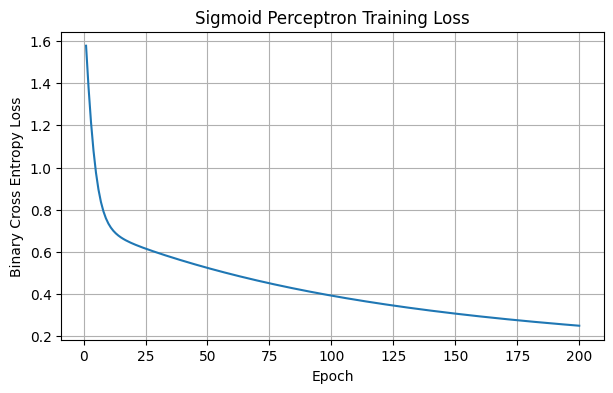

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Sigmoid Perceptron Training Loss")
plt.grid(True)
plt.show()


## 16. Evaluate Sigmoid Perceptron

In [16]:
sigmoid_model.eval()

with torch.no_grad():
    y_test_prob = sigmoid_model(X_test_s_t)
    y_test_pred_t = (y_test_prob >= 0.5).float()

y_test_pred = y_test_pred_t.detach().cpu().numpy().flatten()
y_test_true = y_test_s_t.detach().cpu().numpy().flatten()

sigmoid_accuracy = accuracy_score(y_test_true, y_test_pred)

print("Predicted probabilities:")
print(y_test_prob.detach().cpu().numpy().flatten())

print("\nPredicted classes:")
print(y_test_pred)

print("\nActual classes:")
print(y_test_true)

print("\nAccuracy:", round(sigmoid_accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred))


Predicted probabilities:
[0.17114827 0.10524842 0.15317759 0.15044248 0.08041059 0.08482127
 0.6191712  0.59626657 0.63283783 0.6698333  0.61208296 0.6577692
 0.08624904 0.06483839 0.08487626 0.06516013 0.1749234  0.0747151
 0.07166135 0.09019943 0.61630195 0.11488175 0.61377126 0.08624904
 0.6844326  0.06771923 0.2166347  0.6487929  0.27314165 0.23891109
 0.59521866 0.6528312  0.05963838 0.21567674 0.06456996 0.0779634
 0.659851   0.10523567]

Predicted classes:
[0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.]

Actual classes:
[0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.]

Accuracy: 100.0 %

Confusion Matrix:
[[25  0]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        25
         1.0       1.00      1.00      1.00        13

    accuracy                        

## 17. Manual Input Prediction with Sigmoid Model

In [17]:
def predict_manual_sigmoid(sepal_length, sepal_width, petal_length, petal_width):
    manual_input = torch.tensor(
        [[sepal_length, sepal_width, petal_length, petal_width]],
        dtype=torch.float32,
        device=device
    )

    sigmoid_model.eval()

    with torch.no_grad():
        probability = sigmoid_model(manual_input).item()

    predicted_class = 1 if probability >= 0.5 else 0

    if predicted_class == 1:
        label = "Iris-setosa"
    else:
        label = "Not Iris-setosa"

    return label, probability


# Example manual input
label, probability = predict_manual_sigmoid(
    sepal_length=5.1,
    sepal_width=3.5,
    petal_length=1.4,
    petal_width=0.2
)

print("Prediction:", label)
print("Probability of Iris-setosa:", round(probability, 4))


Prediction: Iris-setosa
Probability of Iris-setosa: 0.6574


## 18. Interactive Manual Input for Sigmoid Model

Run this cell if you want to type values manually.


In [18]:
# Uncomment this cell when you want to enter values manually.

# sepal_length = float(input("Enter sepal length: "))
# sepal_width = float(input("Enter sepal width: "))
# petal_length = float(input("Enter petal length: "))
# petal_width = float(input("Enter petal width: "))

# label, probability = predict_manual_sigmoid(sepal_length, sepal_width, petal_length, petal_width)

# print("Prediction:", label)
# print("Probability of Iris-setosa:", round(probability, 4))


# Final Observations

## Classic Perceptron

The classic perceptron uses a step activation function and produces outputs as either `1` or `-1`.  
The model updates its weights manually whenever the predicted output is different from the actual label.

## Sigmoid Perceptron

The sigmoid version uses labels `1` and `0`.  
Instead of directly producing a hard class, it first produces a probability between 0 and 1.  
The final class is selected using a threshold of 0.5.

## Key Learning

In TensorFlow/Keras, many steps are hidden inside functions such as `model.fit()`.  
In PyTorch, the training loop is usually written manually, which makes the forward pass, loss calculation, backward pass, and optimizer update easier to understand.
